The Knowledge graph contains the following nodes in its graph:
UcoexCPE
UcoCVE
UcoVulnerability
UcoExpolitTarget
UcoCWE
UcoexObservedExample

The nodes are connected to each other in somewhat of a straight line from one type of note to the other. The relationship is as follows:

UcoexCPE <- UCOEXHASCPE -- UcoCVE <- UCOHASCVE_ID -- UcoVulnerability <- UCOHASVULNERABILITY -- UcoExpolitTarget -- UCOHASWEAKNESS -> UcoCWE -- UCOHASOBSERVEDEXAMPLE -> UcoexObservedExample

A second node group also exists between the following nodes:
UcoexGROUPS
UcoexSOFTWARE
UcoexTACTICS
UcoexMITREATTACK
UcoexMITRED3FEND
UcoexMITIGATIONS



This Notebook will seek to do the following:
- Observe the amount of CVEs that have occured each year based on its severity and ability to allow for full admin access
- Observe CPEs to see whether applications, operating systems, or hardware are the most common targets of attacks and compare this data to the severity and admin access capability of its connected CVEs
- Compare CWEs to see which weaknesses are the most connected to CVEs of higher severity and administrator access AND if specific weaknesses are more tied to attacks on CPE parts
- CWEs will also recieve a more in depth analysis to further understand the makeup of the nodes
- Observe CAPECs to understand the common attack patterns that attackers use to aquire full admin access or achieve high CVE severity along with seeing what the attacks impact usually is, Compare the severities of the attack patterns to see if more severe attacks are being used for higher CVE severity or admin access, and how much detail there is regarding these attacks.
- understand the various methods and what devices and users are usually targeted through the ATTACK and DEFEND nodes.


This analysis will help to show how observing the different properties of each of the different nodes together helps to create more indepth analysis for anyone trying to understand vulnerabilities and the various different aspects surrounding them. It will help to show possible hidden connections between vulnerabilities, weaknesses, attack patterns, and affected applications and systems. It can also show an example of how the knowledge graph can be used to analyze and make connections with the nodes to help understand recent trends in cybersecurity and attacks.


In [3]:
#install needed libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
from neo4j import GraphDatabase
import os

Creates a connection to the database

In [4]:
#connect to the database and estabilish that connection was successful
URI = "bolt://localhost:7687"
AUTH = ("neo4j","abcd90909090")

try:
    with GraphDatabase.driver(URI, auth=AUTH) as driver:
        driver.verify_connectivity()
        print("Connection established.")
except Exception as e:
    print("Error connecting to neo4j")
    print(e)


Connection established.


The main function that will run the queries created

In [5]:
#define functions to use
#run_query attempts to run any query given to it
def run_query(query, parameters= None):
    try:
        with driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]
    except Exception as e:
        print(f"Error running query: {e}")
        return []

# CVE Analysis

CVEs are basic reports about vulnerabilities, including basic information regarding vulnerabilities including severity, ability ro gain administrator access, needing user interaction, and more. This will be the basic starting point for the analysis.

Firstly, a count must be taken to see how many CVE nodes exist in the knowledge graph

In [6]:
#runs a query to see how many CVEs are currently in the knowledge graph
CVE_count = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count
"""

params = {}
count = run_query(CVE_count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_32808\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count
0,308297


The label of the CVE contains important information that can be used to analyze the nodes. The label if the CVE is divided as follows:

CVE - (year) - (id)

Year will give the year the CVE was reported by a four digit number. Using this section of the label, we can see how many CVEs were created each year. Based on the created bar graph, there has been a stark increase in created CVEs per year starting around 2017.

In [7]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year
    ORDER BY Year ASC
"""

params = {}
count = run_query(CVE_count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

print(df)

df.plot(x='Year', y='Total_CVE_Count', kind='bar')
plt.title('Total amount of CVEs per year')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

   Total_CVE_Count
0           308297


C:\Users\peyto\AppData\Local\Temp\ipykernel_32808\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


KeyError: 'Year'

something to also note is the severity of each CVEs. CVEs with higher scores in their severity ranking are considered much more dangerous and there is more effort to address those reports.

Overall the severity is important to analyze, but its also important to see how many reports of each severity happened each year. Overall CVEs were usually listed as Medium severity, with High severity following not too far behind. Very rarely were CVEs ranked as low.

It was noticed that in the recent years, severity scores along with impact and expolitability scores were left blank. The following chart visualizes the amount of CVEs each year that have an empty field for severity. This likely reason is that the NVD scoring is being outsourced and it may be possible that they arr not reporting Severity in a different JSON output that the graph is not equipped to handle.

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Severity             HIGH     LOW   MEDIUM
Year                                      
1999         39.0   807.0   165.0    568.0
2000          6.0   527.0   128.0    581.0
2001         19.0   725.0   174.0    638.0
2002         37.0  1085.0   162.0   1109.0
2003         52.0   693.0    96.0    714.0
2004         63.0  1067.0   242.0   1335.0
2005        143.0  1866.0   415.0   2345.0
2006        151.0  2954.0   527.0   3511.0
2007        122.0  3125.0   234.0   3099.0
2008        173.0  3503.0   219.0   3282.0
2009        144.0  2252.0   212.0   2441.0
2010        197.0  2189.0   326.0   2532.0
2011        278.0  1751.0   311.0   2546.0
2012        502.0  1766.0   570.0   3099.0
2013        648.0  2010.0   625.0   3536.0
2014        598.0  2184.0   680.0   5537.0
2015        709.0  2773.0   771.0   4513.0
2016       1308.0  3202.0   935.0   5115.0
2017       2485.0  4201.0  1452.0   8885.0
2018       1803.0  3635.0  1757.0  10300.0
2019       1590.0  3988.0  1849.0   9607.0
2020       

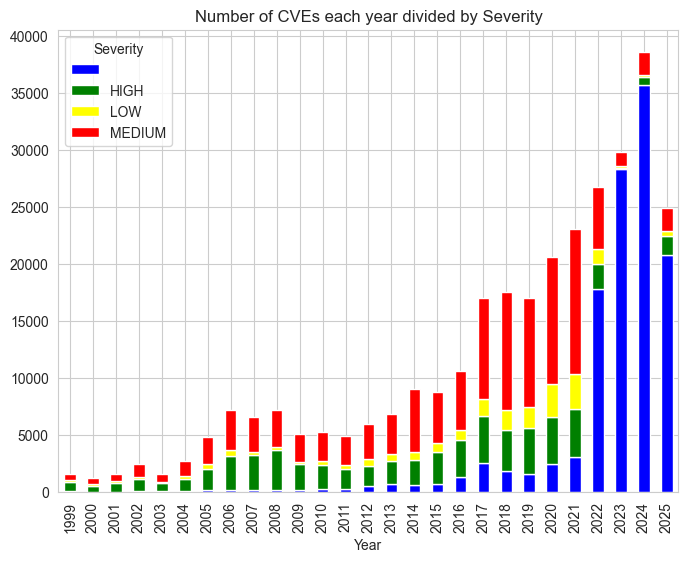

In [ ]:
#makes a more detailed bar graph showing the amount of severity counts each year
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'Total_CVE_Count')
print(pivot)

colors = ['Blue', 'Green', 'Yellow', 'Red']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by Severity')
plt.show()

One of the more important properties is ObtainAllPrivilege. This property allows for an attacker to gain full administrator access to a device or an application. Its important to see if these types of vulnerabilities are becoming more common

Something unusual is that the number of CVEs that allowed for full administrator access has actually increased. The year where the most of theses types of vulnerabilities were reported was in 2007, with 998 total vulnerabilities allowing for admin access. The most recent reports of these types of vulnerabilities was in 2022. Since then there has not been a reported instance of a vulnerability allowing full privilege access. 

    Total_CVE_Count  Year
0               443  1999
1               314  2000
2               299  2001
3               313  2002
4               233  2003
5               434  2004
6               254  2005
7               506  2006
8               998  2007
9               736  2008
10              280  2009
11              150  2010
12               13  2011
13               17  2012
14                9  2013
15               30  2014
16               62  2015
17               53  2016
18               49  2017
19               17  2018
20                2  2019
21                3  2020
22                8  2021
23                2  2022


C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


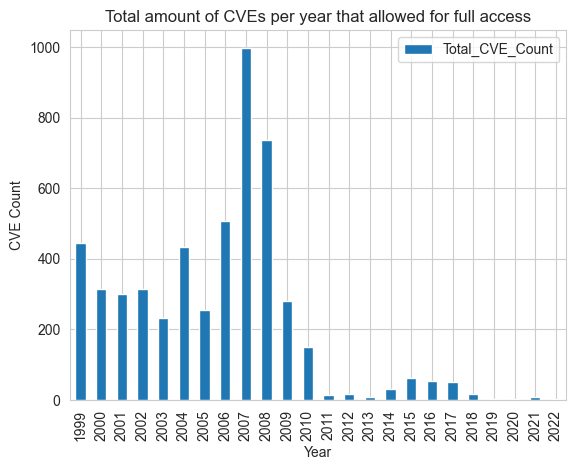

In [ ]:
query = """
    MATCH (n:UcoCVE)
    WHERE n.ucoobtainAllPrivilege = 'true'
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

df.plot(x='Year', y='Total_CVE_Count', kind='bar')
plt.title('Total amount of CVEs per year that allowed for full access')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

# CPEs and its relationship to CVEs

CPEs are nodes that describe what the vulnerability affects. This includes information about the affected publisher, the product, and other important information. This information can be analyzed to see what types of vulnerabilities are affected which publishers and products.

First, CPEs must be analyzed by themselves before being observed with CVEs. First a count is gather of the amount of CPE nodes that are present in the knowledge graph.

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CPE_count
0,138459


One of the more important properties of CPE nodes is the label. The label is a string that is divided to present important information about the node. The string is formatted as follows:

CPE:2.3:(part):(publisher):(product):(version):(update):(edition):(language):(sw_edition):(target software):(target hardware):(other)

Previous workbook reports on CPE nodes have analyzed the publishers and the products that are listed in these labels. One of the more important pieces of this string is the part. The part is a single character that describe what exactly was affected in the CPE. The key for this is:

a - application/
o - operating system/
h - hardware

Considering that the part shows exactly was was affected, the CPEs can be analyzed to see how many affected each of the three parts.

As expressed in the graph below, the majority of CPEs were affecting applications. Operating systems were also not too far behind. Hardware was consider rather rare to be affected having barely a thousand entries.


C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CPE_count Part
0            80386    a
1            56343    o
2             1730    h


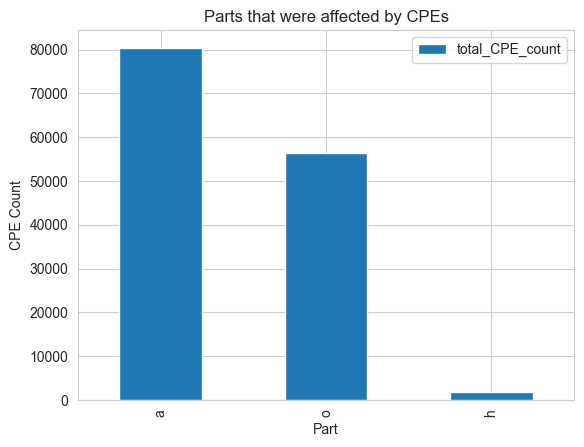

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

df.plot(x='Part', y='total_CPE_count', kind='bar')
plt.title('Parts that were affected by CPEs')
plt.xlabel('Part')
plt.ylabel('CPE Count')
plt.show()

Taking this data some important questions can be asked. For example, how many CPEs affect each of the three parts each year? To grab the year the lastModified property was obtained to grab when the CPE was last updated. This date may not be the day the CPE was created, but rather references the last time it was updated. This is likely why there are no entries for CPEs between 1999-2006.

The graph shows that for each year, applications contained the majority of the CPEs for that year. However, starting at 2020, there was a rapid increase in CPEs that affected operating systems that the amount became higher than the CPEs affecting applications. This is especially seen in 2023, with over 11 thousand CPEs affecting operating systems. This data likely shows a shift in what parts attackers are targeting, with more of a focus being placed on operating systems rather than applications

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
2007        753.0      60.0             225.0
2008        659.0      61.0             176.0
2009        175.0       2.0              28.0
2010        505.0       1.0              71.0
2011        299.0       7.0              87.0
2012       1531.0      31.0             111.0
2013       1040.0      55.0             111.0
2014       2183.0      29.0             103.0
2015        796.0      32.0             182.0
2016        632.0      52.0             153.0
2017        408.0       1.0             105.0
2018        661.0      10.0             174.0
2019       3892.0      12.0            1090.0
2020       3833.0      35.0            4111.0
2021       3317.0     142.0            7448.0
2022       2355.0      17.0            4341.0
2023       3335.0      72.0           11710.0
2024       1105.0      15.0            1148.0
2025       1119.0       NaN             694.0


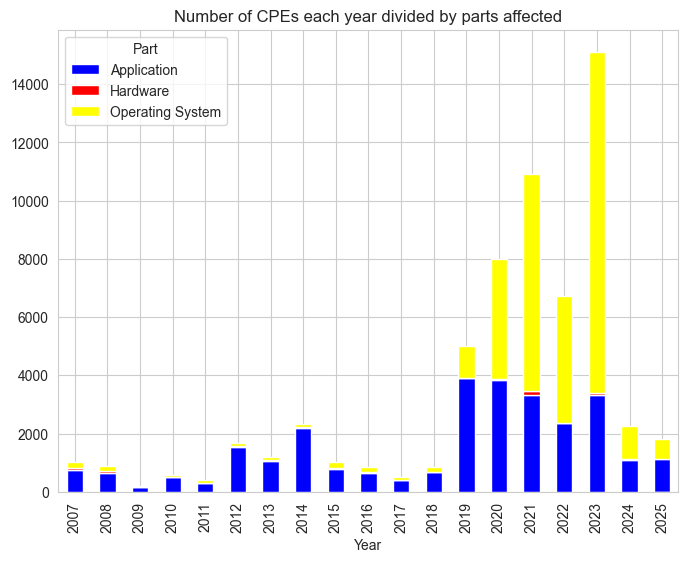

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part, split(toString(n.lastModified), '-')[0] as Year
ORDER BY Year DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CPE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

colors = ['Blue', 'Red', 'Yellow',]

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CPEs each year divided by parts affected')
plt.show()

Using this conclusion that CPEs affecting operating systems are increasing, we can observe and see which operating system products are being affected. The graph below finds the top 15 operating systems based on quantity of CPEs

Based on the chart, ios and linux based operating systems are the biggest targets. Ios is an operating system for mobile devices and Linux is often utilized by programmers and developers. By attacking these products, attackers are taking advantage of products that are widely used and contain lots of information.

C:\Users\peyto\AppData\Local\Temp\ipykernel_32808\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


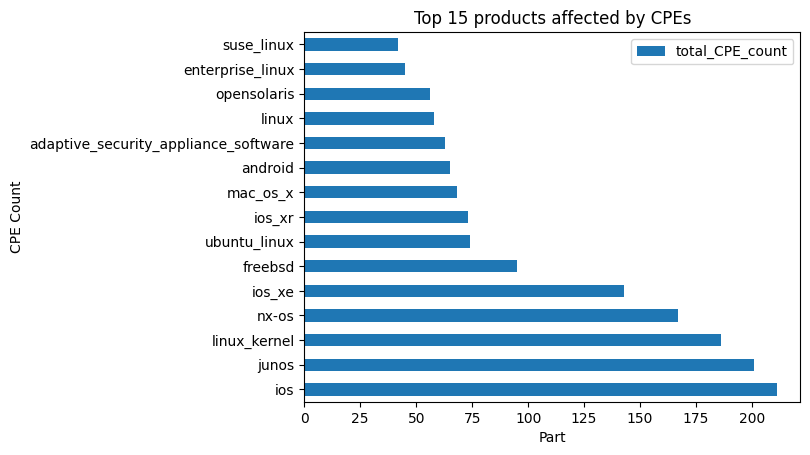

In [8]:
query = """
MATCH (n:UcoexCPE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[4] as Part
ORDER BY total_CPE_count DESC
LIMIT 15
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

df.plot(x='Part', y='total_CPE_count', kind='barh')
plt.title('Top 15 products affected by CPEs')
plt.xlabel('Part')
plt.ylabel('CPE Count')
plt.show()


# CPEs and CVEs

CPEs are connected to CVEs through the relationship UCOEXHASCPE. A single CPE can have multiple CVEs connected to it. However some CVEs are not connected to any CPEs at all, however this is likely due to delays in the connection.

Taking the previous information that was gathered through individual analysis on CPEs, this can then be combined with CVEs to further tie it to vulnerabilities.

Taking the fact that CPEs can have several CVEs connected to them through this relationship, there should be a count showing how many CVEs are connected to applications, hardware, or operating systems. This then can also be divided by year to further develop the CVEs

THis further shows that attacks related to operating systems have been increasing. Hardware related CVEs aren't really seen showing that barely any CVEs are not really related to hardware CPEs and that these are still extremely rare. This can help show which parts are more of the target and where security measures likely need to focus on.

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
1999        743.0      53.0             732.0
2000        922.0      37.0             320.0
2001       1166.0      75.0             381.0
2002       1937.0     128.0             414.0
2003       1224.0      42.0             306.0
2004       2282.0     116.0             547.0
2005       4049.0     138.0             596.0
2006       6380.0     167.0             602.0
2007       5624.0     236.0             934.0
2008       6418.0     196.0             794.0
2009       4691.0     151.0             792.0
2010       5621.0     110.0            1150.0
2011       5137.0      65.0            1069.0
2012       6370.0     134.0            1220.0
2013       7333.0     181.0            2237.0
2014       8421.0      90.0            3636.0
2015       7885.0      89.0            6430.0
2016       9332.0     238.0            7077.0
2017      12470.0      30.0           14965.0
2018      14584.0     145.0       

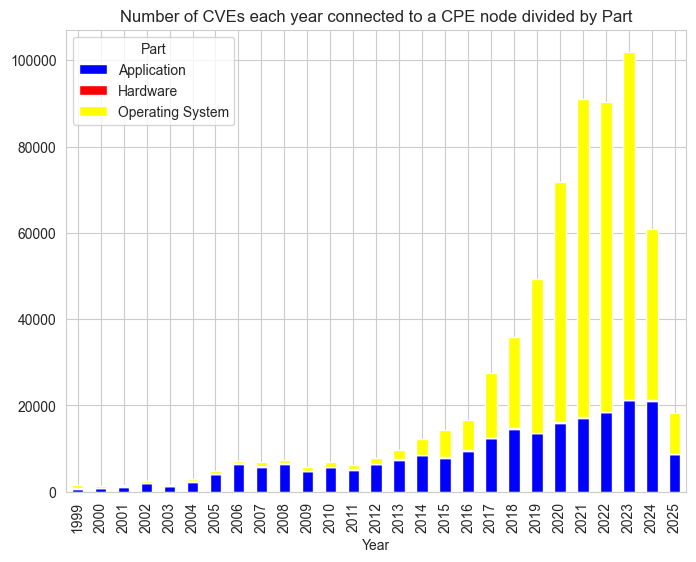

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
RETURN COUNT(n) as total_CVE_count,split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year connected to a CPE node divided by Part')
plt.show()

The previous chart shows that CVEs connected to CPEs are more likely to be tied to operating system attacks than application attacks in the later years, however one question that remains is how severe the CVEs are that affected operating systems. The next bar graph displays all CVEs affecting operating systems dividing them by their severity.

The graph shows that CVEs that affected operating systems seemed to usually be listed as a high or a medium severity. An important note is that because of the current issue with documenting severity when its calculated through different methods, the graph may be innaccurate because of this error.

A pie chart shows that only 12% of operating system related CVEs were considered low severity. Meanwhile, medium and high severity CVEs related to operating systems were both 29%, meaning that it was an even split between an operating system related CVE being medium or high.

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Severity              HIGH     LOW   MEDIUM
Year                                       
1999          NaN    418.0    89.0    225.0
2000          NaN    162.0    48.0    110.0
2001          NaN    170.0    83.0    128.0
2002          NaN    183.0    64.0    167.0
2003          NaN    154.0    36.0    116.0
2004          NaN    251.0    99.0    197.0
2005          NaN    206.0   158.0    232.0
2006          NaN    213.0   100.0    289.0
2007          NaN    472.0    81.0    381.0
2008          NaN    389.0    52.0    353.0
2009          NaN    345.0    56.0    391.0
2010          NaN    445.0   148.0    557.0
2011          NaN    363.0   109.0    597.0
2012          NaN    516.0   142.0    562.0
2013          NaN    843.0   176.0   1218.0
2014          5.0   1636.0   308.0   1687.0
2015          1.0   3349.0   370.0   2710.0
2016         14.0   3838.0   480.0   2745.0
2017        181.0   6113.0  1559.0   7112.0
2018        431.0   8405.0  1314.0  11020.0
2019        157.0  15154.0  5207

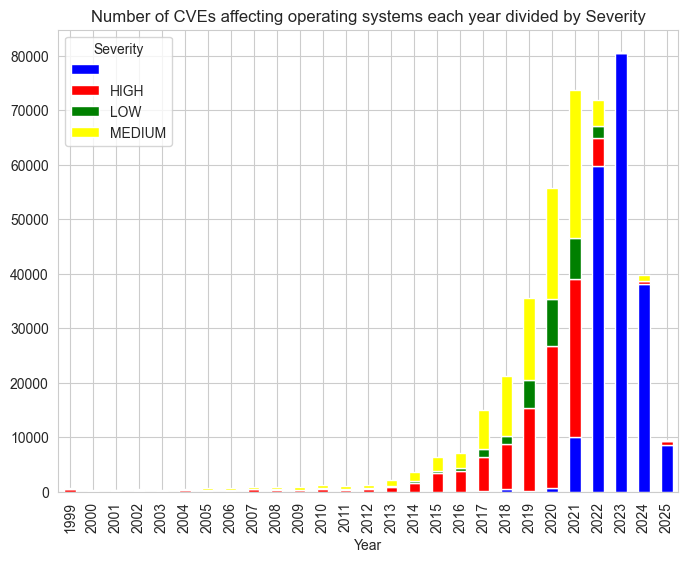

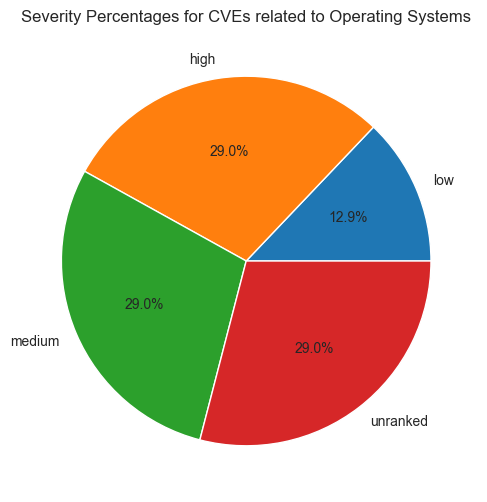

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE split(c.cpeName, ':')[2] = 'o'
RETURN COUNT(n) as total_CVE_count,split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Green', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs affecting operating systems each year divided by Severity')
plt.show()

Severity_count = df['Severity'].value_counts().sort_values(ascending=True)

sb.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(Severity_count, labels=['low', 'high', 'medium', 'unranked'], autopct='%1.1f%%')
plt.title('Severity Percentages for CVEs related to Operating Systems')
plt.show()

Another question that can be asked is which CPE parts are more connected to CVEs that allow for full administrator access.

The graph shows that CVEs that allow for full administrator access were more tied to applications rather than operating systems. 2021 is a bit of an outlier as the majority of CVEx that cause full admin access did target operating systems. However for the majority of years, Applications were the main target. This shows that applications are likely more vulnerable to full access.

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part      a     h      o
Year                    
1999  162.0   8.0  315.0
2000  194.0   8.0  134.0
2001  205.0   3.0  113.0
2002  230.0  17.0   92.0
2003  164.0   5.0   83.0
2004  355.0  13.0  159.0
2005  177.0   2.0   81.0
2006  402.0  23.0  111.0
2007  774.0  43.0  314.0
2008  624.0  39.0  170.0
2009  284.0  13.0   86.0
2010  209.0   3.0   77.0
2011   16.0   1.0    6.0
2012   16.0   2.0    NaN
2013    4.0   3.0    2.0
2014   32.0   2.0    8.0
2015   22.0   2.0   44.0
2016   45.0   5.0   33.0
2017   28.0   NaN   58.0
2018   18.0   NaN    4.0
2019    1.0   NaN    1.0
2020    2.0   NaN    1.0
2021    4.0   NaN  263.0
2022    2.0   NaN    NaN


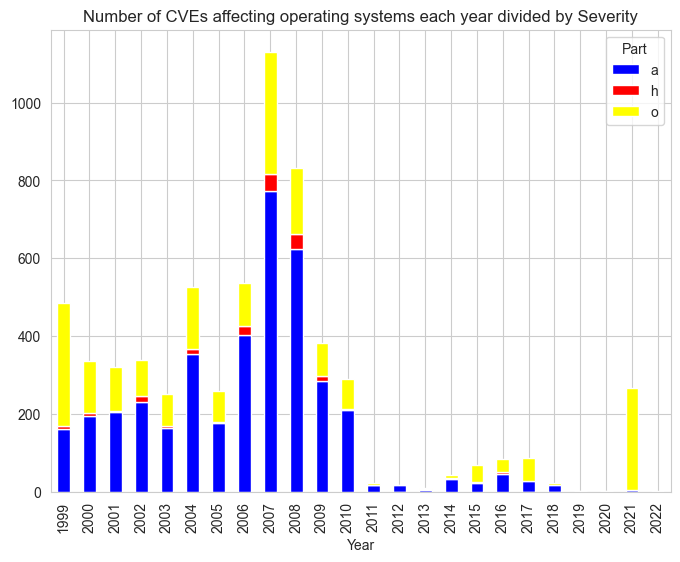

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucoobtainAllPrivilege = 'true'
RETURN COUNT(n) as total_CVE_count, split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs affecting operating systems each year divided by Severity')
plt.show()

# CWEs

CWE nodes discuss common weaknesses that can be found. The amount of CWEs is far less than other nodes in the knowledge graph but are equally as important and contain vital information. This is because sometimes CVEs are tied to specific weaknesses and can help further explain how the vulnerability occured.

Before comparing CWEs to other nodes, CWEs themselves must be understood. Firstly its important to see how many CWEs are present in the knowledge graph

In [10]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_32808\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count
0,969


C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


    Total  Year
0      39  1999
1       6  2000
2      19  2001
3      37  2002
4      52  2003
5      63  2004
6     143  2005
7     151  2006
8     122  2007
9     173  2008
10    144  2009
11    197  2010
12    278  2011
13    502  2012
14    648  2013
15    598  2014
16    709  2015
17   1308  2016
18   2485  2017
19   1803  2018
20   1590  2019
21   2420  2020
22   3035  2021
23  17808  2022
24  28329  2023
25  35681  2024
26  20761  2025


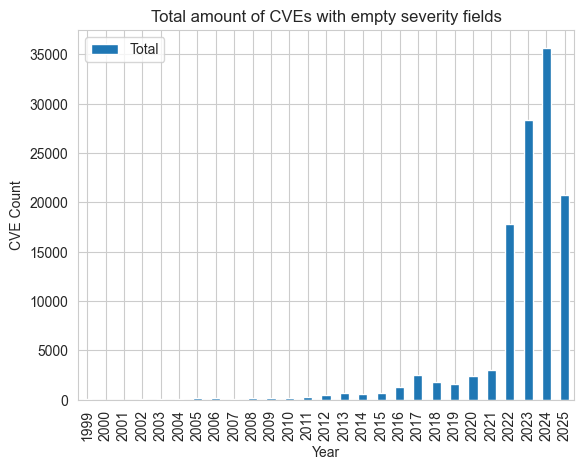

In [ ]:
#runs a query collecting all of the CVE nodes that are connected to CPE nodes through the UCOEXHASCPE relationship
query = """
MATCH (n:UcoCVE)
WHERE n.ucobaseSeverity = ""
RETURN count(DISTINCT n) as Total, split(n.label, '-')[1] as Year
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

df.plot(x='Year', y='Total', kind='bar')
plt.title('Total amount of CVEs with empty severity fields')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

In [ ]:
#preparing to make graphs analyzing the data
#run a query to make a data frame that matches the CVEs related to UcoexCPE by UCOEXHASCPE
#will grab the following:
#CVE Label
#Year it was reported
#Severity Ranking
#Application affected
#null values and duplicates will be excluded from this query but NULL and EMPTY values will be examined later

query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucobaseSeverity <> ""
RETURN DISTINCT n.label as ID,split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity, split(c.cpeName, ':')[3] as Organization
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ID,Year,Severity,Organization
0,CVE-1999-1029,1999,HIGH,ssh
1,CVE-1999-1055,1999,HIGH,microsoft
2,CVE-1999-1077,1999,MEDIUM,apple
3,CVE-1999-1066,1999,MEDIUM,sgi
4,CVE-1999-1083,1999,MEDIUM,t._hauck
...,...,...,...,...
216373,CVE-2025-5896,2025,MEDIUM,taro
216374,CVE-2025-5895,2025,MEDIUM,metabase
216375,CVE-2025-5881,2025,MEDIUM,fabianros
216376,CVE-2025-5887,2025,MEDIUM,jsnjfz


The chart excludes the CVE's that are not connected to CPE nodes. CVEs take a while to be connected to a CPE, so the results are likely to differ greatly from 2021

Year
1999     1509
2000     1265
2001     1598
2002     2427
2003     1553
2004     2882
2005     4737
2006     7066
2007     6645
2008     7242
2009     5196
2010     5543
2011     5044
2012     6167
2013     7143
2014     9939
2015     9983
2016    11638
2017    16569
2018    19238
2019    19440
2020    22426
2021    23459
2022    10282
2023     1524
2024     2767
2025     3096
Name: count, dtype: int64


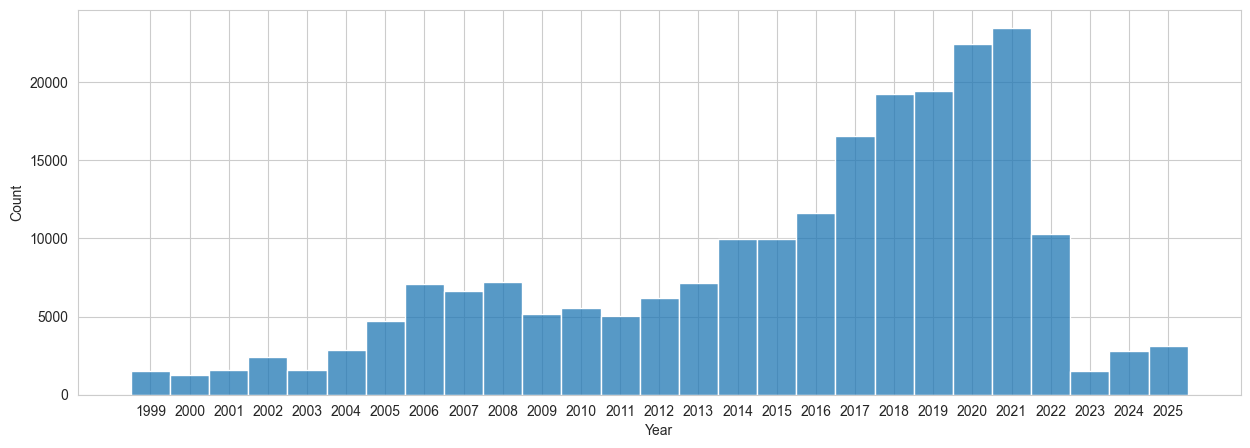

In [ ]:
#taking that dataframe, the first analysis done is to see how many vulnerabilities were
#reported by CVEs each year
#creating a bar graph to display the number of instances for each year
year_count = df['Year'].value_counts().sort_index()
print(year_count)

graph = sb.histplot(df, x='Year')
graph.figure.set_size_inches(15, 5)

Severity
LOW        22535
HIGH       65762
MEDIUM    128081
Name: count, dtype: int64


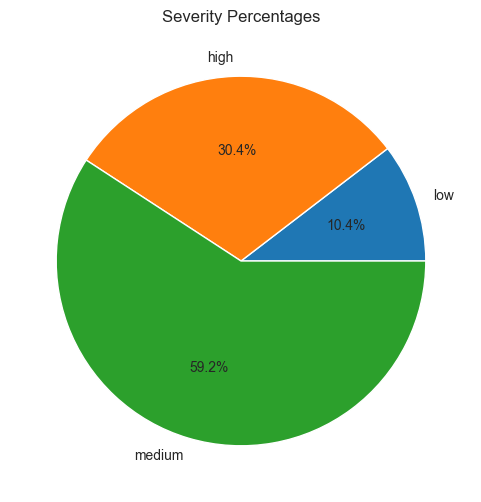

In [ ]:
#next we will look at the severity ranking of the overall data.
#the rankings are as follows: low, medium, and high
#create a graph that displays a count of all of the CVEs showing the percentages
Severity_count = df['Severity'].value_counts().sort_values(ascending=True)
print(Severity_count)

sb.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(Severity_count, labels=['low', 'high', 'medium'], autopct='%1.1f%%')
plt.title('Severity Percentages')
plt.show()

Give a CVE Counts per year by Severity as a bar chart

In [ ]:
#count how many distinct applications were affected
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE split(c.cpeName, ':')[3] IS NOT NULL AND n.ucobaseSeverity <> "" 
RETURN count(DISTINCT split(c.cpeName, ':')[3]) as Application_affected, split(n.label, '-')[1] as Year
ORDER BY split(n.label, '-')[1]
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df




C:\Users\peyto\AppData\Local\Temp\ipykernel_18872\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Application_affected,Year
0,343,1999
1,412,2000
2,575,2001
3,855,2002
4,620,2003
5,993,2004
6,1725,2005
7,2725,2006
8,2594,2007
9,2656,2008
